In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# Indic LLMLingua-2 Training

This notebook fine-tunes the LLMLingua-2 token classification model on an extended Indic dataset constructed from the original LLMLingua-2 dataset and additional XL-Sum supervision.

The objective is binary token classification, where each token is classified as either retained (1) or removed (0) during context compression.

The notebook includes:

- Dataset loading
- Model training
- Validation
- Automatic checkpointing
- Training logs
- Metric tracking
- Artifact generation

In [2]:
PROJECT_DIR = "/kaggle/working/indic_llmlingua"

DATA_DIR = "/kaggle/input/indic-llmlingua-dataset"

CHECKPOINT_DIR = os.path.join(PROJECT_DIR, "checkpoints")

LOG_DIR = os.path.join(PROJECT_DIR, "logs")

PLOT_DIR = os.path.join(PROJECT_DIR, "plots")

PREDICTION_DIR = os.path.join(PROJECT_DIR, "predictions")

CONFIG_DIR = os.path.join(PROJECT_DIR, "configs")

for directory in [
    PROJECT_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    PLOT_DIR,
    PREDICTION_DIR,
    CONFIG_DIR
]:
    os.makedirs(directory, exist_ok=True)

print("Project directory created.")

Project directory created.


# Install Dependencies

In [3]:
!nvidia-smi
!pip install evaluate   

Thu Aug  6 11:08:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [4]:
import torch

print(torch.__version__)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

2.10.0+cu128
True
2
Tesla T4
Tesla T4


# Import Libraries

In [5]:
import os
import json
import random
import numpy as np
import pandas as pd

from datasets import Dataset

import torch

from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
)

import evaluate

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

In [6]:
!git clone https://github.com/microsoft/LLMLingua.git
!ls LLMLingua

Cloning into 'LLMLingua'...
remote: Enumerating objects: 505, done.
remote: Counting objects: 100% (255/255), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 505 (delta 210), reused 165 (delta 165), pack-reused 250 (from 1)
Receiving objects: 100% (505/505), 4.02 MiB | 9.27 MiB/s, done.
Resolving deltas: 100% (281/281), done.
CODE_OF_CONDUCT.md  images     pyproject.toml  setup.py
DOCUMENT.md	    LICENSE    README.md       SUPPORT.md
examples	    llmlingua  SECURITY.md     tests
experiments	    Makefile   setup.cfg       Transparency_FAQ.md


In [7]:
!pwd
!ls

/kaggle/working
indic_llmlingua  LLMLingua


## Load Training Dataset

The dataset consists of token-level binary labels for context compression.

Each sample contains:

- question
- original_answer
- tokens
- labels

The dataset is stored in JSONL format.

In [8]:
INPUT_DIR = "/kaggle/input"

print("Available Datasets:\n")

for dataset in os.listdir(INPUT_DIR):
    print(dataset)

Available Datasets:



In [9]:
import os

DATASET_PATH = "/kaggle/input/datasets"

print("=" * 80)
print("Dataset Contents")
print("=" * 80)

for root, dirs, files in os.walk(DATASET_PATH):
    level = root.replace(DATASET_PATH, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    sub_indent = " " * 4 * (level + 1)
    for file in files:
        print(f"{sub_indent}{file}")

Dataset Contents


In [11]:
DATASET_PATH = "/kaggle/input/datasets/hiteshpanghal79/indic-lingua-data"

In [12]:
from datasets import load_dataset

DATASET_PATH = "/kaggle/input/datasets/hiteshpanghal79/indic-lingua-data"

dataset = load_dataset(
    "json",
    data_files={
        "train": f"{DATASET_PATH}/train.jsonl",
        "validation": f"{DATASET_PATH}/val.jsonl",
        "test": f"{DATASET_PATH}/test.jsonl",
    },
)

print(dataset)

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 1609
    })
    validation: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 201
    })
    test: Dataset({
        features: ['question', 'original_answer', 'tokens', 'labels'],
        num_rows: 202
    })
})


In [13]:
print("Train Samples      :", len(dataset["train"]))
print("Validation Samples :", len(dataset["validation"]))
print("Test Samples       :", len(dataset["test"]))

sample = dataset["train"][0]

print("\nColumns:")
print(sample.keys())

print("\nQuestion:")
print(sample["question"])

print("\nOriginal Answer:")
print(sample["original_answer"])

print("\nFirst 20 Tokens:")
print(sample["tokens"][:20])

print("\nFirst 20 Labels:")
print(sample["labels"][:20])

print("\nTotal Tokens:", len(sample["tokens"]))
print("Total Labels:", len(sample["labels"]))

Train Samples      : 1609
Validation Samples : 201
Test Samples       : 202

Columns:
dict_keys(['question', 'original_answer', 'tokens', 'labels'])

Question:
अमरीकी वैज्ञानिकों ने एच5एन1 वायरस के बारे में क्या पुष्टि की है और इससे मनुष्यों के लिए क्या खतरा बढ़ गया है?

Original Answer:
अमरीकी वैज्ञानिकों ने पुष्टि की है कि एच5एन1 वायरस दो अलग विषाणुओं में बदल चुका है, जिससे मनुष्यों के लिए खतरा बढ़ गया है।

First 20 Tokens:
['विश्व', 'स्वास्थ्य', 'संगठन', 'ने', 'बताया', 'है', 'कि', 'बर्ड', 'फ़्लू', 'के', 'एच5एन1', 'वायरस', 'से', 'मौत', 'के', 'ताज़ा', 'मामले', 'अज़रबैजान', 'में', 'सामने']

First 20 Labels:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

Total Tokens: 256
Total Labels: 256


# Experiment Configuration

This section defines the experiment configuration and fixes all random seeds to ensure reproducible training.

Using a fixed random seed ensures that data shuffling, weight initialization, and training behaviour remain consistent across runs.

In [14]:
import os
import random
import numpy as np
import torch

# ==========================================================
# Experiment Configuration
# ==========================================================

MODEL_NAME = "FacebookAI/xlm-roberta-base"

MAX_LENGTH = 512

NUM_LABELS = 2

SEED = 42

OUTPUT_DIR = "/kaggle/working/outputs"

CHECKPOINT_DIR = os.path.join(OUTPUT_DIR, "checkpoints")

LOG_DIR = os.path.join(OUTPUT_DIR, "logs")

PREDICTION_DIR = os.path.join(OUTPUT_DIR, "predictions")

PLOT_DIR = os.path.join(OUTPUT_DIR, "plots")

CONFIG_DIR = os.path.join(OUTPUT_DIR, "configs")

for directory in [
    OUTPUT_DIR,
    CHECKPOINT_DIR,
    LOG_DIR,
    PREDICTION_DIR,
    PLOT_DIR,
    CONFIG_DIR,
]:
    os.makedirs(directory, exist_ok=True)

print("Directories created successfully.")

Directories created successfully.


In [15]:
def set_seed(seed: int = 42):

    random.seed(seed)

    np.random.seed(seed)

    torch.manual_seed(seed)

    torch.cuda.manual_seed(seed)

    torch.cuda.manual_seed_all(seed)

    os.environ["PYTHONHASHSEED"] = str(seed)

    torch.backends.cudnn.deterministic = True

    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print(f"Random Seed Fixed : {SEED}")

Random Seed Fixed : 42


In [16]:
import json

experiment_config = {

    "model_name": MODEL_NAME,

    "max_length": MAX_LENGTH,

    "num_labels": NUM_LABELS,

    "seed": SEED,

}

with open(os.path.join(CONFIG_DIR, "experiment_config.json"), "w") as fp:
    json.dump(experiment_config, fp, indent=4)

print("Experiment configuration saved.")

Experiment configuration saved.


# Tokenizer

The multilingual XLM-RoBERTa tokenizer is used to tokenize the input while preserving the alignment between words and token-level labels.

Since XLM-RoBERTa uses SentencePiece tokenization, a single word may be split into multiple subword tokens. During training, labels are assigned only to the first subword, while subsequent subwords are ignored using the label value `-100`.

In [17]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    use_fast=True
)

print("Tokenizer Loaded Successfully")

config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer Loaded Successfully


In [18]:
sample = dataset["train"][0]

encoding = tokenizer(
    sample["tokens"],
    is_split_into_words=True
)

print("Original Tokens :", len(sample["tokens"]))
print("Encoded Tokens  :", len(encoding["input_ids"]))

Original Tokens : 256
Encoded Tokens  : 392


# Tokenization and Label Alignment

The dataset contains labels at the word level, whereas XLM-RoBERTa operates at the subword level.

During tokenization, a single word may be split into multiple subword tokens. To maintain correct supervision:

- The original label is assigned only to the first subword.
- Remaining subwords are ignored during loss computation by assigning a label of `-100`.
- Special tokens and padding tokens are also assigned `-100`.

This follows the standard Hugging Face token classification pipeline.

In [19]:
IGNORE_LABEL = -100

def tokenize_and_align_labels(examples):
    """
    Tokenize input tokens and align word-level labels with subword tokens.
    """

    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        max_length=MAX_LENGTH,
    )

    aligned_labels = []

    for batch_index in range(len(examples["tokens"])):

        word_ids = tokenized.word_ids(batch_index=batch_index)
        labels = examples["labels"][batch_index]

        previous_word = None
        label_ids = []

        for word_id in word_ids:

            # Special tokens (<s>, </s>, padding)
            if word_id is None:
                label_ids.append(IGNORE_LABEL)

            # First subword of a word
            elif word_id != previous_word:
                label_ids.append(labels[word_id])

            # Remaining subwords
            else:
                label_ids.append(IGNORE_LABEL)

            previous_word = word_id

        aligned_labels.append(label_ids)

    tokenized["labels"] = aligned_labels

    return tokenized

In [20]:
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    batched=True,
    remove_columns=dataset["train"].column_names,
    desc="Tokenizing Dataset"
)

Tokenizing Dataset:   0%|          | 0/1609 [00:00<?, ? examples/s]

Tokenizing Dataset:   0%|          | 0/201 [00:00<?, ? examples/s]

Tokenizing Dataset:   0%|          | 0/202 [00:00<?, ? examples/s]

In [21]:
sample = tokenized_dataset["train"][0]

print("Input IDs :", len(sample["input_ids"]))
print("Labels    :", len(sample["labels"]))
print("Attention :", len(sample["attention_mask"]))

Input IDs : 392
Labels    : 392
Attention : 392


In [22]:
tokens = tokenizer.convert_ids_to_tokens(sample["input_ids"])

for token, label in zip(tokens[:50], sample["labels"][:50]):
    print(f"{token:<20} {label}")

<s>                  -100
▁विश्व               1
▁स्वास्थ्य           1
▁संगठन               1
▁ने                  1
▁बताया               1
▁है                  1
▁कि                  1
▁बर्                 1
ड                    -100
▁फ़                  1
्ल                   -100
ू                    -100
▁के                  1
▁एच                  1
5                    -100
एन                   -100
1                    -100
▁                    1
वाय                  -100
रस                   -100
▁से                  1
▁मौत                 1
▁के                  1
▁ताज़ा               1
▁मामले               1
▁अ                   1
ज़र                  -100
बै                   -100
जान                  -100
▁में                 1
▁सामने               1
▁आए                  1
▁हैं                 1
.                    -100
▁अ                   1
ज़र                  -100
बै                   -100
जान                  -100
▁में                 1
▁फ़                  1
र        

In [23]:
tokenized_dataset.set_format(
    type="torch",
    columns=[
        "input_ids",
        "attention_mask",
        "labels",
    ],
)

# Data Collator

The data collator dynamically pads input sequences within each batch during training.

Instead of padding every sample in the dataset to a fixed maximum length, dynamic padding minimizes unnecessary computation and improves GPU utilization.

Labels are padded using the ignore index (`-100`) so that padding tokens do not contribute to the loss.

In [24]:
from transformers import DataCollatorForTokenClassification

data_collator = DataCollatorForTokenClassification(
    tokenizer=tokenizer,
    padding=True
)

print("Data Collator Initialized Successfully")

Data Collator Initialized Successfully


# Metrics

In [25]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
)

IGNORE_LABEL = -100


def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    true_predictions = []
    true_labels = []

    for pred_seq, label_seq in zip(predictions, labels):
        for pred, label in zip(pred_seq, label_seq):

            # Ignore padding & continuation subwords
            if label == IGNORE_LABEL:
                continue

            true_predictions.append(pred)
            true_labels.append(label)

    precision, recall, f1, _ = precision_recall_fscore_support(
        true_labels,
        true_predictions,
        average="binary",
        zero_division=0,
    )

    accuracy = accuracy_score(
        true_labels,
        true_predictions,
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }

In [26]:
print(compute_metrics)

<function compute_metrics at 0x7e4f2940cea0>


# Model Initialization

The training objective is binary token classification.

The pretrained multilingual XLM-RoBERTa encoder is initialized with a token classification head consisting of two output classes:

- 0 → Remove Token
- 1 → Keep Token

The encoder weights are initialized from the pretrained checkpoint, while the classification head is initialized randomly and optimized during fine-tuning.

In [27]:
from transformers import AutoModelForTokenClassification

id2label = {
    0: "REMOVE",
    1: "KEEP"
}

label2id = {
    "REMOVE": 0,
    "KEEP": 1
}

model = AutoModelForTokenClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2,
    id2label=id2label,
    label2id=label2id,
)

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
roberta.pooler.dense.bias   | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
classifier.weight           | MISSING    | 
classifier.bias             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [28]:
model.gradient_checkpointing_enable()

print("Gradient Checkpointing Enabled")

Gradient Checkpointing Enabled


In [29]:
print(model.config)

XLMRobertaConfig {
  "add_cross_attention": false,
  "architectures": [
    "XLMRobertaForMaskedLM"
  ],
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": 0,
  "classifier_dropout": null,
  "dtype": "float32",
  "eos_token_id": 2,
  "hidden_act": "gelu",
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "REMOVE",
    "1": "KEEP"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "KEEP": 1,
    "REMOVE": 0
  },
  "layer_norm_eps": 1e-05,
  "max_position_embeddings": 514,
  "model_type": "xlm-roberta",
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "output_past": true,
  "pad_token_id": 1,
  "position_embedding_type": "absolute",
  "tie_word_embeddings": true,
  "transformers_version": "5.0.0",
  "type_vocab_size": 1,
  "use_cache": true,
  "vocab_size": 250002
}



In [30]:
total_params = sum(p.numel() for p in model.parameters())

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")

Total Parameters     : 277,454,594
Trainable Parameters : 277,454,594


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)

print(device)

cuda


# Training Configuration

The model is fine-tuned using the Hugging Face Trainer API.

Model checkpoints are automatically saved after every epoch while retaining the best-performing model based on the validation F1-score.

Mixed precision (FP16) training is enabled to improve training speed and reduce GPU memory consumption.

In [90]:
# import os
# from transformers import TrainingArguments

# # TensorBoard log directory
# os.environ["TENSORBOARD_LOGGING_DIR"] = LOG_DIR

# training_args = TrainingArguments(
#     output_dir=CHECKPOINT_DIR,

#     # Training
#     num_train_epochs=10,
#     learning_rate=2e-5,

#     per_device_train_batch_size=8,
#     per_device_eval_batch_size=8,
#     gradient_accumulation_steps=2,

#     # Optimization
#     weight_decay=0.01,
#     warmup_steps=100,

#     # Evaluation
#     eval_strategy="epoch",
#     save_strategy="epoch",

#     logging_strategy="steps",
#     logging_steps=20,

#     # Save best model
#     load_best_model_at_end=True,
#     metric_for_best_model="f1",
#     greater_is_better=True,

#     save_total_limit=2,

#     # Mixed Precision
#     fp16=True,

#     report_to="tensorboard",

#     seed=SEED,
# )

In [91]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [92]:
# from datetime import datetime
# import json

# experiment = {
#     "date": str(datetime.now()),
#     "model": MODEL_NAME,
#     "epochs": 10,
#     "learning_rate": 2e-5,
#     "batch_size": 8,
#     "gradient_accumulation": 2,
#     "max_length": 512,
#     "optimizer": "AdamW",
#     "scheduler": "Linear",
#     "weight_decay": 0.01,
#     "warmup_steps": 100,
# }

# with open(f"{CONFIG_DIR}/experiment.json","w") as f:
#     json.dump(experiment,f,indent=4)

# print("Experiment configuration saved.")

Experiment configuration saved.


In [32]:
import torch

print("CUDA Available :", torch.cuda.is_available())

print("GPU Count :", torch.cuda.device_count())

for i in range(torch.cuda.device_count()):
    print(torch.cuda.get_device_name(i))

CUDA Available : True
GPU Count : 2
Tesla T4
Tesla T4


In [94]:
# from transformers import EarlyStoppingCallback

# early_stopping = EarlyStoppingCallback(
#     early_stopping_patience=2,
#     early_stopping_threshold=0.0
# )

# print("Early stopping callback initialized.")

Early stopping callback initialized.


In [95]:
# from transformers import Trainer

# trainer = Trainer(
#     model=model,
#     args=training_args,

#     train_dataset=tokenized_dataset["train"],
#     eval_dataset=tokenized_dataset["validation"],

#     processing_class=tokenizer,

#     data_collator=data_collator,

#     compute_metrics=compute_metrics
# )

# Hyperparameter Tuning

This section performs a hyperparameter search over the fine-tuning configuration (learning rate, batch size, weight decay, warmup steps) prior to the final full training run below.

For every hyperparameter combination in `HYPERPARAM_GRID`:

- A fresh XLM-RoBERTa model is instantiated (so experiments do not leak weights into one another).
- The model is trained for `TUNING_EPOCHS` epochs on the training split.
- Training loss, validation loss, and validation F1 are logged after every evaluation.
- A per-experiment plot (train loss, val loss, val F1) is generated and saved to `PLOT_DIR`.

At the end, all experiments are compared and the best configuration (by validation F1) is selected and saved to `CONFIG_DIR/best_hyperparameters.json`. You can then use that configuration in the "Training Configuration" section below for the final full-length training run.

In [96]:
# ==========================================================
# Hyperparameter Grid
# ==========================================================
# Each entry is one experiment configuration. Feel free to edit / extend
# this grid with any other TrainingArguments-compatible keys.

HYPERPARAM_GRID = [
    {
        "learning_rate": 1e-5,
        "per_device_train_batch_size": 8,
        "weight_decay": 0.01,
        "warmup_steps": 100,
    },
    {
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 8,
        "weight_decay": 0.01,
        "warmup_steps": 100,
    },
    {
        "learning_rate": 3e-5,
        "per_device_train_batch_size": 16,
        "weight_decay": 0.01,
        "warmup_steps": 200,
    },
    {
        "learning_rate": 2e-5,
        "per_device_train_batch_size": 8,
        "weight_decay": 0.1,
        "warmup_steps": 100,
    },
]

# Number of epochs used during the tuning phase (kept small so the search
# is fast; increase for a more thorough search).
TUNING_EPOCHS = 3

TUNING_DIR = os.path.join(OUTPUT_DIR, "hyperparameter_search")
os.makedirs(TUNING_DIR, exist_ok=True)

print(f"Number of hyperparameter configurations to try: {len(HYPERPARAM_GRID)}")
for i, cfg in enumerate(HYPERPARAM_GRID):
    print(f"  Experiment {i}: {cfg}")

Number of hyperparameter configurations to try: 4
  Experiment 0: {'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01, 'warmup_steps': 100}
  Experiment 1: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01, 'warmup_steps': 100}
  Experiment 2: {'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.01, 'warmup_steps': 200}
  Experiment 3: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.1, 'warmup_steps': 100}


In [101]:
# ==========================================================
# Helper: run a single hyperparameter experiment
# ==========================================================
from transformers import (
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback,
)


def run_experiment(config, exp_id):
    """Train and evaluate a single hyperparameter configuration.

    Returns a dict with the config, the trainer log history, and the
    final validation metrics.
    """

    print("=" * 80)
    print(f"Experiment {exp_id}: {config}")
    print("=" * 80)

    # Fresh model + seed for every experiment so runs are independent
    set_seed(SEED)

    exp_model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
    )
    exp_model.gradient_checkpointing_enable()
    exp_model.to(device)

    exp_output_dir = os.path.join(TUNING_DIR, f"experiment_{exp_id}")
    os.makedirs(exp_output_dir, exist_ok=True)

    exp_training_args = TrainingArguments(
        output_dir=exp_output_dir,

        num_train_epochs=config.get("num_train_epochs", TUNING_EPOCHS),
        learning_rate=config.get("learning_rate", 2e-5),

        per_device_train_batch_size=config.get("per_device_train_batch_size", 8),
        per_device_eval_batch_size=config.get("per_device_eval_batch_size", 8),
        gradient_accumulation_steps=config.get("gradient_accumulation_steps", 2),

        weight_decay=config.get("weight_decay", 0.01),
        warmup_steps=config.get("warmup_steps", 100),

        eval_strategy="epoch",
        save_strategy="no",

        logging_strategy="steps",
        logging_steps=20,

        load_best_model_at_end=False,
        metric_for_best_model="f1",
        greater_is_better=True,

        save_total_limit=1,

        fp16=True,

        report_to="none",

        seed=SEED,
        disable_tqdm=False,
    )

    exp_trainer = Trainer(
        model=exp_model,
        args=exp_training_args,

        train_dataset=tokenized_dataset["train"],
        eval_dataset=tokenized_dataset["validation"],

        processing_class=tokenizer,

        data_collator=data_collator,

        compute_metrics=compute_metrics,

        callbacks=[EarlyStoppingCallback(early_stopping_patience=2, early_stopping_threshold=0.0)],
    )

    exp_trainer.train()

    val_metrics = exp_trainer.evaluate()

    result = {
        "exp_id": exp_id,
        "config": config,
        "log_history": exp_trainer.state.log_history,
        "val_metrics": val_metrics,
        "model_dir": exp_output_dir,
    }

    # Free GPU memory before the next experiment
    del exp_trainer
    del exp_model
    torch.cuda.empty_cache()

    return result

In [102]:
# !rm -rf /kaggle/working/*

In [103]:
# ==========================================================
# Helper: plot train loss, val loss, val F1 for one experiment
# ==========================================================
import matplotlib.pyplot as plt


def plot_experiment(result):
    exp_id = result["exp_id"]
    config = result["config"]

    history = pd.DataFrame(result["log_history"])

    train_df = history[history["loss"].notna()] if "loss" in history else pd.DataFrame()
    eval_df = history[history["eval_loss"].notna()] if "eval_loss" in history else pd.DataFrame()

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # Training Loss
    if not train_df.empty:
        axes[0].plot(train_df["step"], train_df["loss"], marker="o")
    axes[0].set_title(f"Exp {exp_id} - Training Loss")
    axes[0].set_xlabel("Training Step")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True)

    # Validation Loss
    if not eval_df.empty:
        axes[1].plot(eval_df["epoch"], eval_df["eval_loss"], marker="o", color="orange")
    axes[1].set_title(f"Exp {exp_id} - Validation Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(True)

    # Validation F1
    if not eval_df.empty and "eval_f1" in eval_df:
        axes[2].plot(eval_df["epoch"], eval_df["eval_f1"], marker="o", color="green")
    axes[2].set_title(f"Exp {exp_id} - Validation F1")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("F1 Score")
    axes[2].grid(True)

    fig.suptitle(f"Experiment {exp_id}: {config}", fontsize=10)
    plt.tight_layout()

    plot_path = os.path.join(PLOT_DIR, f"hp_experiment_{exp_id}.png")
    plt.savefig(plot_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to: {plot_path}")

Experiment 0: {'learning_rate': 1e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01, 'warmup_steps': 100}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.12/dist-packages/torch/au

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.335381,1.041493,0.716409,0.000000,0.000000,0.000000
2,1.880153,0.974865,0.717796,0.540984,0.032280,0.060925
3,1.812078,0.933803,0.738928,0.546830,0.463606,0.501791


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


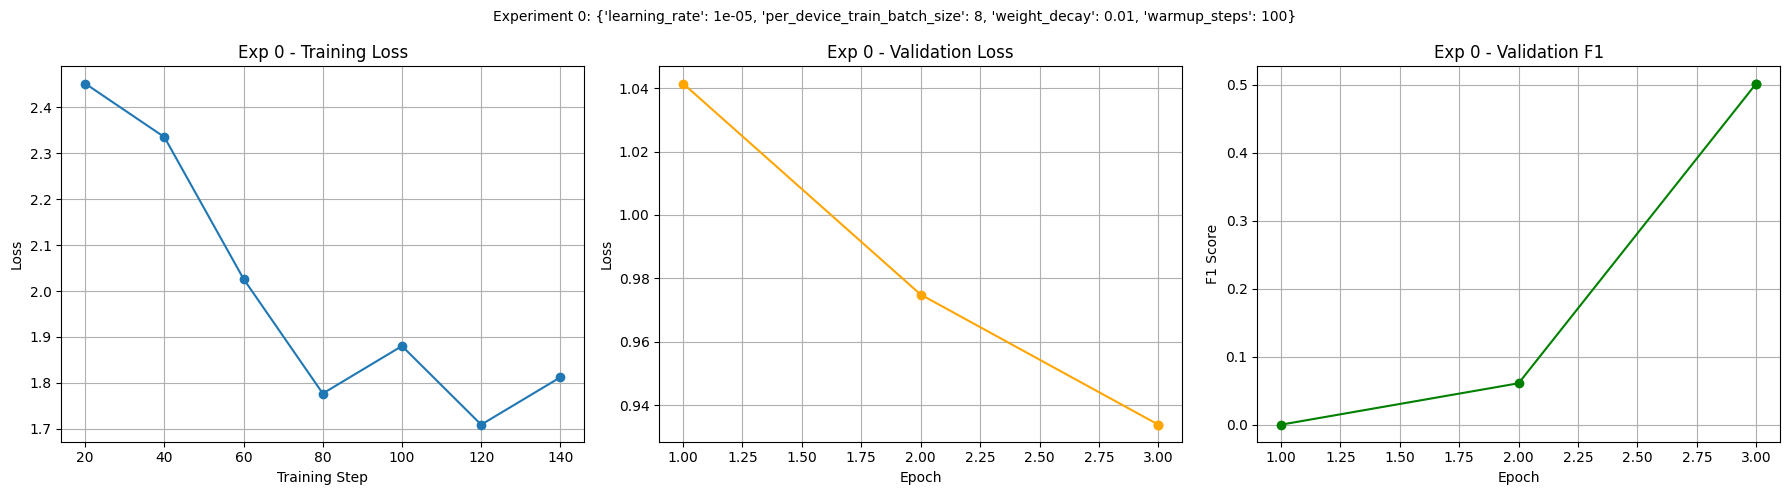

Saved plot to: /kaggle/working/outputs/plots/hp_experiment_0.png
Experiment 1: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01, 'warmup_steps': 100}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.12/dist-packages/torch/au

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.234927,0.948481,0.707369,0.485999,0.553254,0.517450
2,1.862348,0.938116,0.724927,0.589322,0.099085,0.169647
3,1.793592,0.912988,0.744509,0.551171,0.533633,0.542260


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


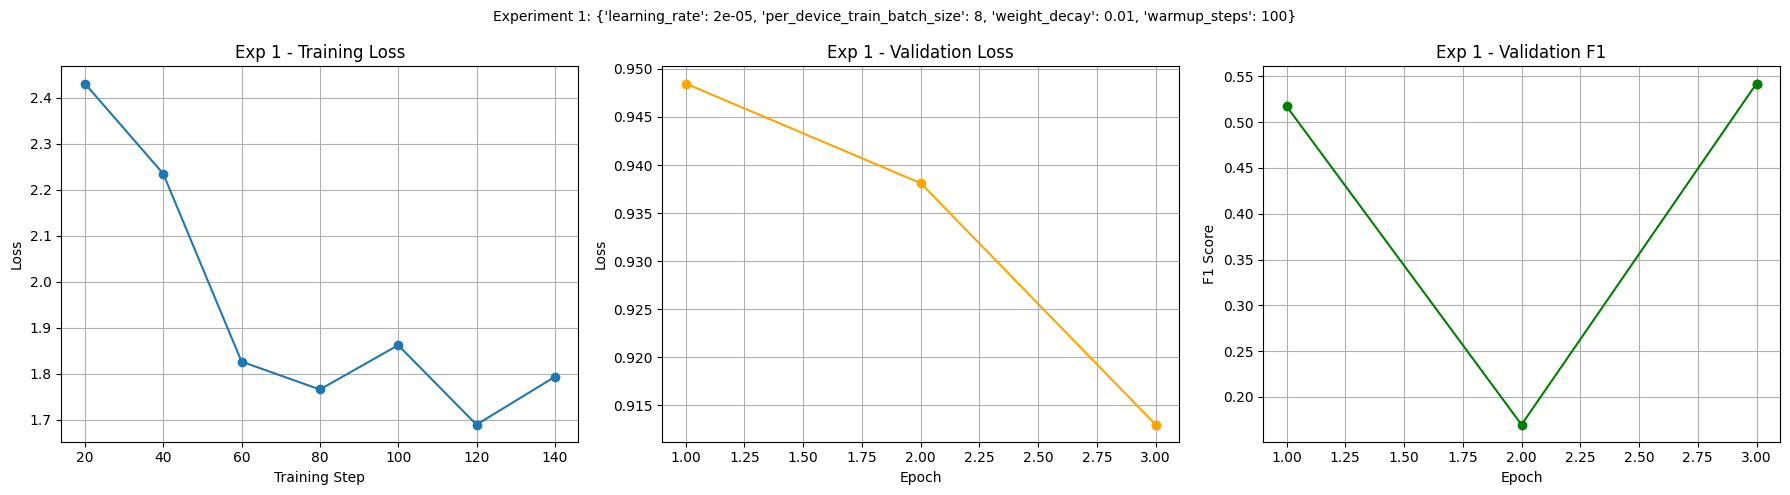

Saved plot to: /kaggle/working/outputs/plots/hp_experiment_1.png
Experiment 2: {'learning_rate': 3e-05, 'per_device_train_batch_size': 16, 'weight_decay': 0.01, 'warmup_steps': 200}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.12/dist-packages/torch/au

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.437906,1.178391,0.716409,0.000000,0.000000,0.000000
2,2.211517,0.952668,0.712363,0.476254,0.143104,0.220079
3,1.825006,0.932724,0.723932,0.518929,0.363600,0.427595


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


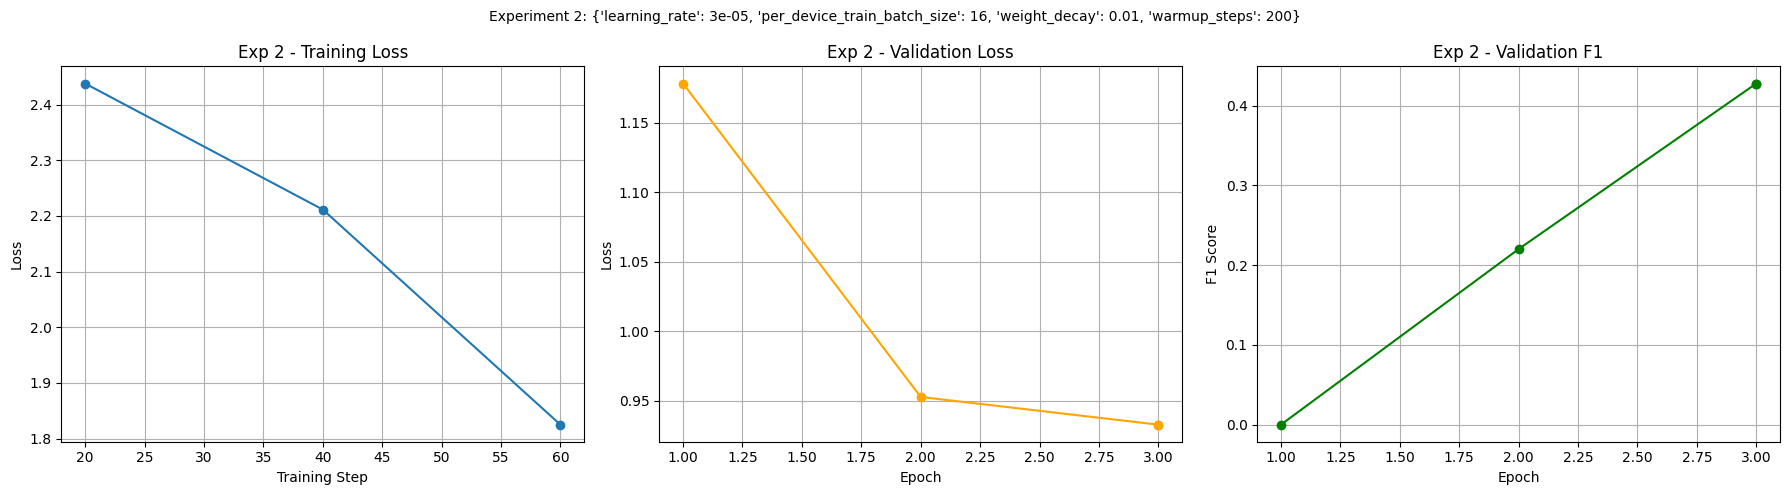

Saved plot to: /kaggle/working/outputs/plots/hp_experiment_2.png
Experiment 3: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.1, 'warmup_steps': 100}


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForTokenClassification LOAD REPORT from: FacebookAI/xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.weight        | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
classifier.bias             | MISSING    | 
classifier.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Using EarlyStoppingCallback without load_best_model_at_end=True. Once training is finished, the best model will not be loaded automatically.
/usr/local/lib/python3.12/dist-packages/torch/au

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.234407,0.948184,0.707239,0.485908,0.557512,0.519253
2,1.857625,0.962893,0.718319,0.622642,0.017090,0.033266
3,1.798386,0.920724,0.748148,0.575971,0.424248,0.488602


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


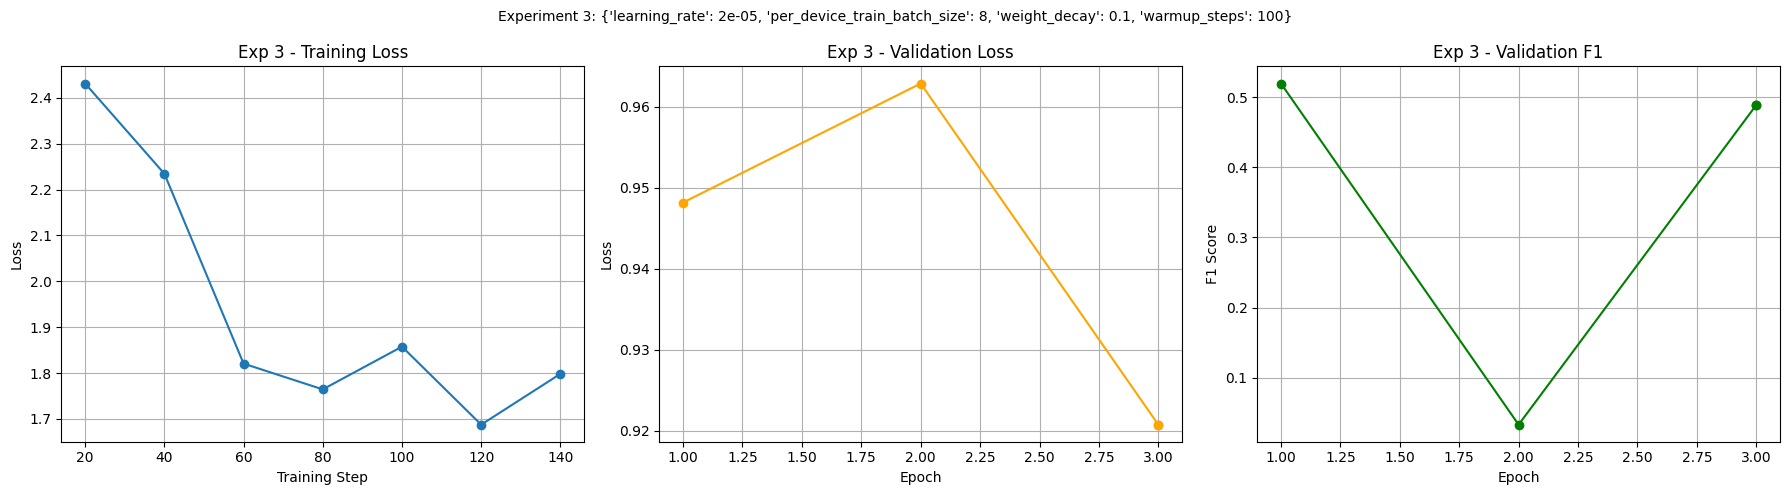

Saved plot to: /kaggle/working/outputs/plots/hp_experiment_3.png
Hyperparameter search complete.


In [104]:
# ==========================================================
# Run the hyperparameter search
# ==========================================================
hyperparameter_results = []

for exp_id, config in enumerate(HYPERPARAM_GRID):
    result = run_experiment(config, exp_id)
    hyperparameter_results.append(result)
    plot_experiment(result)

print("Hyperparameter search complete.")

   learning_rate  per_device_train_batch_size  weight_decay  warmup_steps  \
0        0.00002                            8          0.01           100   
1        0.00001                            8          0.01           100   
2        0.00002                            8          0.10           100   
3        0.00003                           16          0.01           200   

   exp_id  val_loss  val_accuracy  val_precision  val_recall    val_f1  
0       1  0.912988      0.744509       0.551171    0.533633  0.542260  
1       0  0.933803      0.738928       0.546830    0.463606  0.501791  
2       3  0.920724      0.748148       0.575971    0.424248  0.488602  
3       2  0.932724      0.723932       0.518929    0.363600  0.427595  


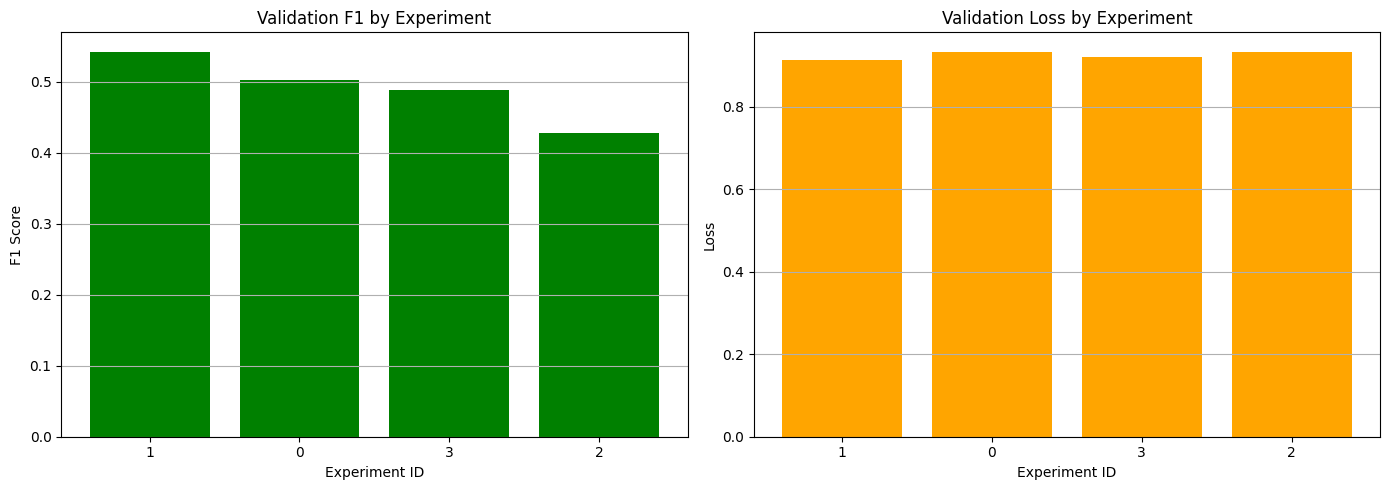


Best experiment: 1
Best config: {'learning_rate': 2e-05, 'per_device_train_batch_size': 8, 'weight_decay': 0.01, 'warmup_steps': 100}
Best validation F1: 0.5423
Best model (experiment 1) saved to: /kaggle/working/outputs/best_hyperparameter_model
Zipped best model available at: /kaggle/working/outputs/best_hyperparameter_model.zip


In [105]:
# ==========================================================
# Compare experiments and select the best configuration
# ==========================================================
summary_rows = []

for result in hyperparameter_results:
    row = dict(result["config"])
    row["exp_id"] = result["exp_id"]
    row["val_loss"] = result["val_metrics"].get("eval_loss")
    row["val_accuracy"] = result["val_metrics"].get("eval_accuracy")
    row["val_precision"] = result["val_metrics"].get("eval_precision")
    row["val_recall"] = result["val_metrics"].get("eval_recall")
    row["val_f1"] = result["val_metrics"].get("eval_f1")
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).sort_values("val_f1", ascending=False).reset_index(drop=True)

print(summary_df)

summary_df.to_csv(os.path.join(TUNING_DIR, "hyperparameter_search_summary.csv"), index=False)

# Comparison bar chart across experiments
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(summary_df["exp_id"].astype(str), summary_df["val_f1"], color="green")
axes[0].set_title("Validation F1 by Experiment")
axes[0].set_xlabel("Experiment ID")
axes[0].set_ylabel("F1 Score")
axes[0].grid(True, axis="y")

axes[1].bar(summary_df["exp_id"].astype(str), summary_df["val_loss"], color="orange")
axes[1].set_title("Validation Loss by Experiment")
axes[1].set_xlabel("Experiment ID")
axes[1].set_ylabel("Loss")
axes[1].grid(True, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(PLOT_DIR, "hp_search_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

best_row = summary_df.iloc[0]
best_exp_id = int(best_row["exp_id"])
best_config = hyperparameter_results[best_exp_id]["config"]

print(f"\nBest experiment: {best_exp_id}")
print(f"Best config: {best_config}")
print(f"Best validation F1: {best_row['val_f1']:.4f}")

# with open(os.path.join(CONFIG_DIR, "best_hyperparameters.json"), "w") as f:
#     json.dump(best_config, f, indent=4)

# print("Best hyperparameters saved to configs/best_hyperparameters.json")

# ==========================================================
# Save the best model from the hyperparameter search
# ==========================================================
import shutil

BEST_HP_MODEL_DIR = os.path.join(OUTPUT_DIR, "best_hyperparameter_model")

best_model_src_dir = hyperparameter_results[best_exp_id]["model_dir"]

if os.path.exists(BEST_HP_MODEL_DIR):
    shutil.rmtree(BEST_HP_MODEL_DIR)

shutil.copytree(best_model_src_dir, BEST_HP_MODEL_DIR)

with open(os.path.join(BEST_HP_MODEL_DIR, "best_config.json"), "w") as f:
    json.dump(best_config, f, indent=4)

with open(os.path.join(BEST_HP_MODEL_DIR, "validation_metrics.json"), "w") as f:
    json.dump(hyperparameter_results[best_exp_id]["val_metrics"], f, indent=4)

print(f"Best model (experiment {best_exp_id}) saved to: {BEST_HP_MODEL_DIR}")

# Zip it up for easy download
shutil.make_archive(BEST_HP_MODEL_DIR, "zip", BEST_HP_MODEL_DIR)
print(f"Zipped best model available at: {BEST_HP_MODEL_DIR}.zip")

## Complete Training Using Best Hyperparameter

In [33]:
import os
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback
from transformers import Trainer



# TensorBoard log directory
os.environ["TENSORBOARD_LOGGING_DIR"] = LOG_DIR

training_args = TrainingArguments(
    output_dir=CHECKPOINT_DIR,

    # Training
    num_train_epochs=20,
    learning_rate=2e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    gradient_accumulation_steps=2,

    # Optimization
    weight_decay=0.01,
    warmup_steps=100,

    # Evaluation
    eval_strategy="epoch",
    save_strategy="epoch",

    logging_strategy="steps",
    logging_steps=20,

    # Save best model
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=2,

    # Mixed Precision
    fp16=True,

    report_to="tensorboard",

    seed=SEED,
)


early_stopping = EarlyStoppingCallback(
    early_stopping_patience=2,
    early_stopping_threshold=0.0
)

print("Early stopping callback initialized.")


trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_dataset["train"],
    eval_dataset=tokenized_dataset["validation"],

    processing_class=tokenizer,

    data_collator=data_collator,

    compute_metrics=compute_metrics
)
train_result = trainer.train()

Early stopping callback initialized.


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,2.235149,0.948543,0.707418,0.486046,0.552161,0.516998
2,1.864820,0.933710,0.728485,0.587886,0.142413,0.229283
3,1.808371,0.913335,0.750906,0.584763,0.419587,0.488593
4,1.820474,0.905828,0.747299,0.558998,0.516025,0.536653
5,1.694102,0.917263,0.741229,0.635828,0.204845,0.309862
6,1.576204,0.953237,0.745912,0.538788,0.722539,0.617279
7,1.619611,1.063166,0.729056,0.513576,0.843489,0.638430
8,1.424208,1.039973,0.727114,0.518651,0.524829,0.521722
9,1.335470,1.084689,0.724340,0.511622,0.615513,0.558780
10,1.267420,1.071069,0.733853,0.533033,0.496289,0.514005


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

In [34]:
val_metrics = trainer.evaluate()

print(val_metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.0638543367385864, 'eval_accuracy': 0.7291700662511015, 'eval_precision': 0.5137144861452122, 'eval_recall': 0.8427412394268945, 'eval_f1': 0.6383229096297588, 'eval_runtime': 4.7154, 'eval_samples_per_second': 42.626, 'eval_steps_per_second': 2.757, 'epoch': 20.0}


In [35]:
test_metrics = trainer.evaluate(tokenized_dataset["test"])

print(test_metrics)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 1.008892297744751, 'eval_accuracy': 0.7471179789060584, 'eval_precision': 0.49591585112121445, 'eval_recall': 0.8438339998688783, 'eval_f1': 0.6246996869463926, 'eval_runtime': 4.7156, 'eval_samples_per_second': 42.837, 'eval_steps_per_second': 2.757, 'epoch': 20.0}


In [36]:
import json
import os

SAVE_DIR = "/kaggle/working/final_model"

trainer.save_model(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

with open(os.path.join(SAVE_DIR, "validation_metrics.json"), "w") as f:
    json.dump(val_metrics, f, indent=4)

with open(os.path.join(SAVE_DIR, "test_metrics.json"), "w") as f:
    json.dump(test_metrics, f, indent=4)

print("Everything saved successfully.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Everything saved successfully.


In [41]:
!ls -lh /kaggle/working

total 24K
drwxr-xr-x 2 root root 4.0K Aug  6 12:28 final_model
drwxr-xr-x 7 root root 4.0K Aug  6 11:08 indic_llmlingua
drwxr-xr-x 9 root root 4.0K Aug  6 11:08 LLMLingua
drwxr-xr-x 7 root root 4.0K Aug  6 11:11 outputs
drwxr-xr-x 2 root root 4.0K Aug  6 12:29 submission_artifacts
-rw-r--r-- 1 root root 2.1K Aug  6 12:29 submission_artifacts.zip


In [42]:
import os
import shutil

artifact_dir = "/kaggle/working/submission_artifacts"
os.makedirs(artifact_dir, exist_ok=True)

# Copy metrics if they exist
for f in [
    "validation_metrics.json",
    "test_metrics.json",
    "training_log.csv",
]:
    src = f"/kaggle/working/final_model/{f}"
    if os.path.exists(src):
        shutil.copy(src, artifact_dir)

# Copy config files
for f in [
    "config.json",
    "tokenizer_config.json",
    "special_tokens_map.json",
]:
    src = f"/kaggle/working/final_model/{f}"
    if os.path.exists(src):
        shutil.copy(src, artifact_dir)

# Zip only artifacts
!zip -r /kaggle/working/submission_artifacts.zip /kaggle/working/submission_artifacts

updating: kaggle/working/submission_artifacts/ (stored 0%)
updating: kaggle/working/submission_artifacts/config.json (deflated 51%)
updating: kaggle/working/submission_artifacts/tokenizer_config.json (deflated 47%)
updating: kaggle/working/submission_artifacts/validation_metrics.json (deflated 45%)
updating: kaggle/working/submission_artifacts/test_metrics.json (deflated 45%)


In [43]:
!find /kaggle/working -type f | sort

/kaggle/working/final_model/config.json
/kaggle/working/final_model/model.safetensors
/kaggle/working/final_model/test_metrics.json
/kaggle/working/final_model/tokenizer_config.json
/kaggle/working/final_model/tokenizer.json
/kaggle/working/final_model/training_args.bin
/kaggle/working/final_model/validation_metrics.json
/kaggle/working/LLMLingua/CODE_OF_CONDUCT.md
/kaggle/working/LLMLingua/DOCUMENT.md
/kaggle/working/LLMLingua/examples/Code.ipynb
/kaggle/working/LLMLingua/examples/CoT.ipynb
/kaggle/working/LLMLingua/examples/LLMLingua2.ipynb
/kaggle/working/LLMLingua/examples/OnlineMeeting.ipynb
/kaggle/working/LLMLingua/examples/RAG.ipynb
/kaggle/working/LLMLingua/examples/RAGLlamaIndex.ipynb
/kaggle/working/LLMLingua/examples/Retrieval.ipynb
/kaggle/working/LLMLingua/experiments/llmlingua2/data_collection/collect_data.sh
/kaggle/working/LLMLingua/experiments/llmlingua2/data_collection/compression_instructions.json
/kaggle/working/LLMLingua/experiments/llmlingua2/data_collection/comp

In [44]:
%reload_ext tensorboard

In [45]:
%tensorboard --logdir /kaggle/working/outputs/logs

<IPython.core.display.Javascript object>

In [46]:
len(trainer.state.log_history)

74

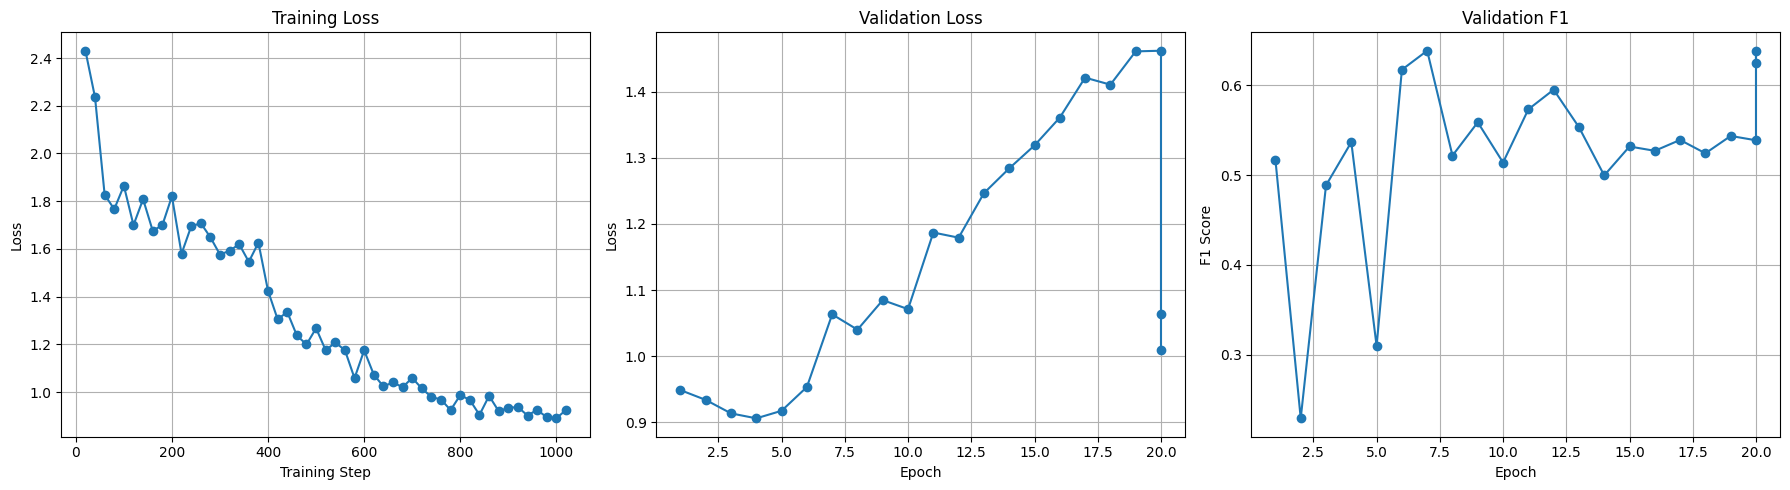

In [47]:
import pandas as pd
import matplotlib.pyplot as plt

history = pd.DataFrame(trainer.state.log_history)

train = history[history["loss"].notna()]
eval_df = history[history["eval_loss"].notna()]

fig, axes = plt.subplots(1, 3, figsize=(18,5))

# ----------------------------
# Training Loss
# ----------------------------
axes[0].plot(train["step"], train["loss"], marker="o")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Training Step")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# ----------------------------
# Validation Loss
# ----------------------------
axes[1].plot(eval_df["epoch"], eval_df["eval_loss"], marker="o")
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].grid(True)

# ----------------------------
# Validation F1
# ----------------------------
axes[2].plot(eval_df["epoch"], eval_df["eval_f1"], marker="o")
axes[2].set_title("Validation F1")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("F1 Score")
axes[2].grid(True)

plt.tight_layout()

plt.savefig(
    "/kaggle/working/training_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


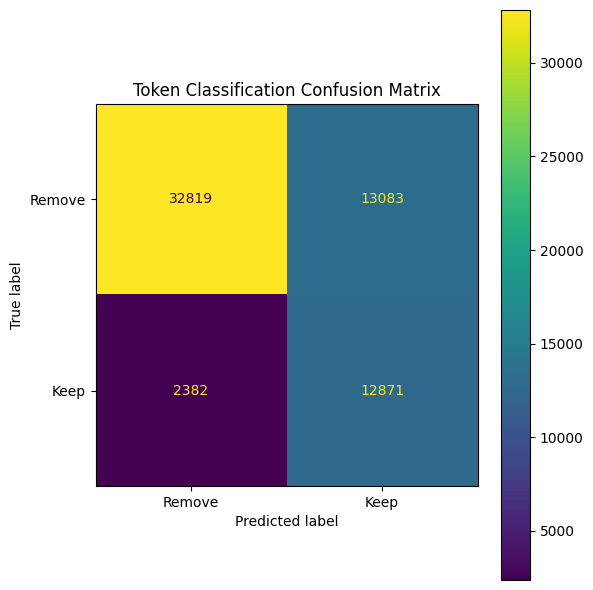

In [48]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

predictions = trainer.predict(tokenized_dataset["test"])

preds = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

y_true = []
y_pred = []

for pred, label in zip(preds, labels):
    for p, l in zip(pred, label):
        if l != -100:
            y_true.append(l)
            y_pred.append(p)

cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(6,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Remove", "Keep"]
)

disp.plot(ax=ax)

plt.title("Token Classification Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "/kaggle/working/confusion_matrix.png",
    dpi=300
)

plt.show()

# ROC Curve

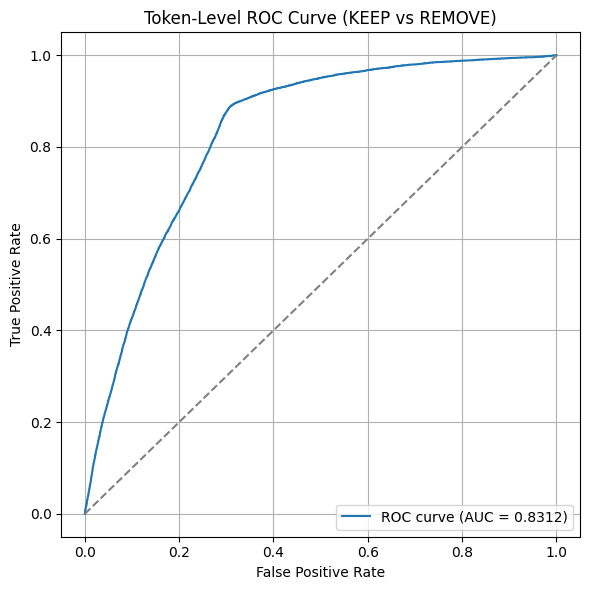

In [49]:
import torch
import numpy as np
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

logits = predictions.predictions
labels = predictions.label_ids
probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()
prob_keep = probs[..., 1]

y_true_flat, y_score_flat = [], []
for prob_seq, label_seq in zip(prob_keep, labels):
    for p, l in zip(prob_seq, label_seq):
        if l != -100:
            y_true_flat.append(l)
            y_score_flat.append(p)

y_true_flat = np.array(y_true_flat)
y_score_flat = np.array(y_score_flat)

fpr, tpr, _ = roc_curve(y_true_flat, y_score_flat)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Token-Level ROC Curve (KEEP vs REMOVE)")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/roc_curve.png", dpi=300)
plt.show()

# Precision-Recall Curve

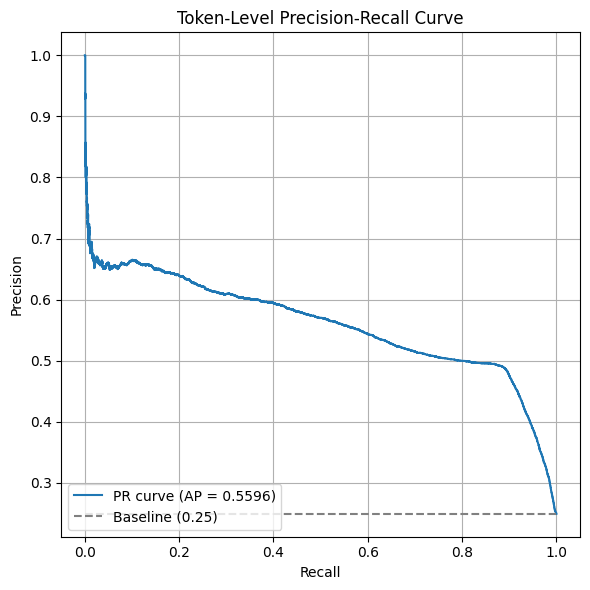

In [50]:
from sklearn.metrics import precision_recall_curve, average_precision_score

precision_vals, recall_vals, _ = precision_recall_curve(y_true_flat, y_score_flat)
pr_auc = average_precision_score(y_true_flat, y_score_flat)

plt.figure(figsize=(6, 6))
plt.plot(recall_vals, precision_vals, label=f"PR curve (AP = {pr_auc:.4f})")
baseline = y_true_flat.mean()
plt.hlines(baseline, 0, 1, linestyle="--", color="gray", label=f"Baseline ({baseline:.2f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Token-Level Precision-Recall Curve")
plt.legend(loc="lower left")
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/pr_curve.png", dpi=300)
plt.show()

# Qualitative Success

In [51]:
id2label_local = {0: "REMOVE", 1: "KEEP"}
preds_per_example = np.argmax(logits, axis=-1)

def decode_example(idx, dataset_split, preds_array, labels_array, tokenizer):
    input_ids = dataset_split[idx]["input_ids"]
    input_ids = input_ids.tolist() if hasattr(input_ids, "tolist") else input_ids
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    rows = []
    for tok, true_l, pred_l in zip(tokens, labels_array[idx], preds_array[idx]):
        if true_l == -100:
            continue
        rows.append((tok, int(true_l), int(pred_l)))
    return rows

example_accuracies = []
for i in range(len(labels)):
    mask = labels[i] != -100
    if mask.sum() >= 15:
        acc = (labels[i][mask] == preds_per_example[i][mask]).mean()
        example_accuracies.append((i, acc))

best_idx = max(example_accuracies, key=lambda x: x[1])[0]
worst_idx = min(example_accuracies, key=lambda x: x[1])[0]

def print_example(idx, title):
    rows = decode_example(idx, tokenized_dataset["test"], preds_per_example, labels, tokenizer)
    print("=" * 80, f"\n{title} (example #{idx})\n" + "=" * 80)
    print(f"{'Token':<20}{'True':<10}{'Pred':<10}{'Match'}")
    for tok, true_l, pred_l in rows:
        match = "OK" if true_l == pred_l else "MISMATCH"
        print(f"{tok:<20}{id2label_local[true_l]:<10}{id2label_local[pred_l]:<10}{match}")

print_example(best_idx, "SUCCESSFUL PREDICTION")
print_example(worst_idx, "FAILURE CASE")

SUCCESSFUL PREDICTION (example #10)
Token               True      Pred      Match
▁अमर                KEEP      KEEP      OK
▁सेना               KEEP      KEEP      OK
▁ने                 KEEP      KEEP      OK
▁इस                 KEEP      KEEP      OK
▁अल                 KEEP      KEEP      OK
▁                   KEEP      KEEP      OK
▁नेता               KEEP      KEEP      OK
▁को                 KEEP      KEEP      OK
▁मो                 KEEP      KEEP      OK
▁का                 KEEP      KEEP      OK
▁निवासी             KEEP      KEEP      OK
▁बताया              KEEP      KEEP      OK
▁है                 KEEP      KEEP      OK
▁वे                 KEEP      KEEP      OK
▁अब                 KEEP      KEEP      OK
▁                   KEEP      KEEP      OK
▁या                 KEEP      KEEP      OK
▁अब                 KEEP      KEEP      OK
▁सारा               KEEP      KEEP      OK
▁के                 KEEP      KEEP      OK
▁नाम                KEEP      KEEP      OK
▁से            

# Error Analysis — class bias (over-keep vs over-remove)

In [52]:
from sklearn.metrics import classification_report

print(classification_report(y_true_flat, y_score_flat > 0.5,
                             target_names=["REMOVE", "KEEP"], digits=4))

false_positive = int(((y_true_flat == 0) & (y_score_flat > 0.5)).sum())
false_negative = int(((y_true_flat == 1) & (y_score_flat <= 0.5)).sum())
print(f"False Positives (kept but should remove): {false_positive}")
print(f"False Negatives (removed but should keep): {false_negative}")

              precision    recall  f1-score   support

      REMOVE     0.9323    0.7150    0.8093     45902
        KEEP     0.4959    0.8438    0.6247     15253

    accuracy                         0.7471     61155
   macro avg     0.7141    0.7794    0.7170     61155
weighted avg     0.8235    0.7471    0.7633     61155

False Positives (kept but should remove): 13083
False Negatives (removed but should keep): 2382


# Error Analysis — error rate vs. sequence length

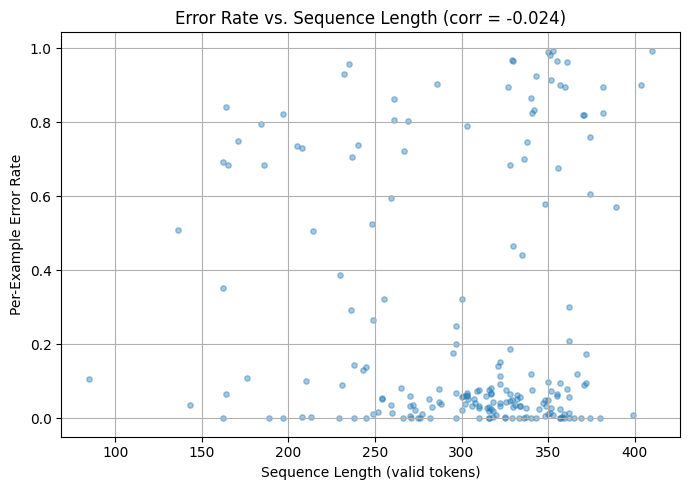

In [53]:
lengths, error_rates = [], []
for i in range(len(labels)):
    mask = labels[i] != -100
    n = mask.sum()
    if n == 0:
        continue
    lengths.append(int(n))
    error_rates.append((labels[i][mask] != preds_per_example[i][mask]).mean())

lengths, error_rates = np.array(lengths), np.array(error_rates)
corr = np.corrcoef(lengths, error_rates)[0, 1]

plt.figure(figsize=(7, 5))
plt.scatter(lengths, error_rates, alpha=0.4, s=15)
plt.xlabel("Sequence Length (valid tokens)")
plt.ylabel("Per-Example Error Rate")
plt.title(f"Error Rate vs. Sequence Length (corr = {corr:.3f})")
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/error_rate_vs_length.png", dpi=300)
plt.show()

**The model performs better as the length of sequence increases**

# Error Analysis — error position within sequence

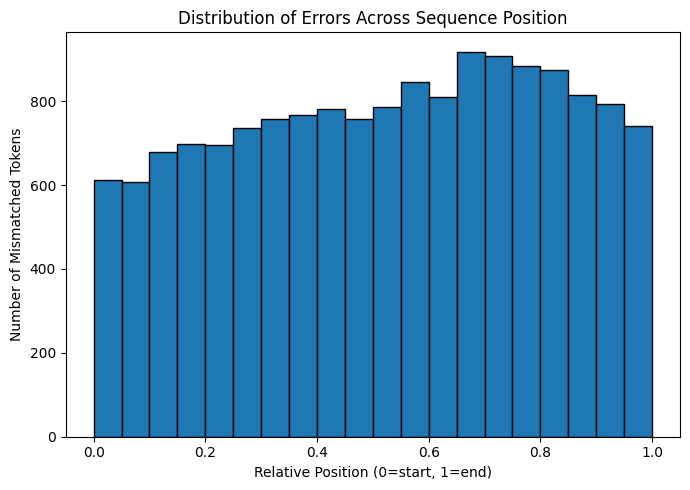

In [56]:
relative_positions = []
for i in range(len(labels)):
    mask = labels[i] != -100
    n = int(mask.sum())
    if n < 2:
        continue
    valid_idx = np.where(mask)[0]
    mismatches = valid_idx[labels[i][valid_idx] != preds_per_example[i][valid_idx]]
    for m in mismatches:
        rank = np.searchsorted(valid_idx, m)
        relative_positions.append(rank / (n - 1))

plt.figure(figsize=(7, 5))
plt.hist(relative_positions, bins=20, edgecolor="black")
plt.xlabel("Relative Position (0=start, 1=end)")
plt.ylabel("Number of Mismatched Tokens")
plt.title("Distribution of Errors Across Sequence Position")
plt.tight_layout()
plt.savefig("/kaggle/working/error_position_distribution.png", dpi=300)
plt.show()

# Error Analysis — most frequently mis-classified tokens

In [55]:
from collections import Counter

error_token_counter, total_token_counter = Counter(), Counter()
for i in range(len(labels)):
    input_ids = tokenized_dataset["test"][i]["input_ids"]
    input_ids = input_ids.tolist() if hasattr(input_ids, "tolist") else input_ids
    tokens = tokenizer.convert_ids_to_tokens(input_ids)
    for tok, true_l, pred_l in zip(tokens, labels[i], preds_per_example[i]):
        if true_l == -100:
            continue
        total_token_counter[tok] += 1
        if true_l != pred_l:
            error_token_counter[tok] += 1

rows = [(tok, c, total_token_counter[tok], c / total_token_counter[tok])
        for tok, c in error_token_counter.items() if total_token_counter[tok] >= 5]
rows.sort(key=lambda r: (-r[3], -r[2]))

print(f"{'Token':<20}{'Errors':<10}{'Occurrences':<15}{'Error Rate'}")
for tok, err_count, total, rate in rows[:20]:
    print(f"{tok:<20}{err_count:<10}{total:<15}{rate:.2%}")

Token               Errors    Occurrences    Error Rate
▁सोना               8         8              100.00%
▁नित्य              7         7              100.00%
▁सेक्स              6         6              100.00%
▁देखी               6         6              100.00%
▁विश्वकप            6         6              100.00%
▁बनाकर              5         5              100.00%
▁वित्तीय            5         5              100.00%
▁टीवी               14        15             93.33%
▁फ़िल्म             19        21             90.48%
▁मां                6         7              85.71%
▁गेंद               6         7              85.71%
▁चिंता              6         7              85.71%
▁जाँच               10        12             83.33%
▁पारी               5         6              83.33%
▁अरुण               5         6              83.33%
▁गिरावट             5         6              83.33%
▁चट                 5         6              83.33%
▁नाका               5         6              83.33%
▁

In [121]:
import os

for file in [
    "/kaggle/working/training_summary.png",
    "/kaggle/working/confusion_matrix.png",
]:
    print(file, os.path.exists(file))

/kaggle/working/training_summary.png True
/kaggle/working/confusion_matrix.png True


In [122]:
import pandas as pd

history = pd.DataFrame(trainer.state.log_history)

history.to_csv(
    "/kaggle/working/training_history.csv",
    index=False
)

history.head()

,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_precision,eval_recall,eval_f1,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,2.430894,1.628746,0.000004,0.396040,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2.232983,5.677652,0.000008,0.792079,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,1.000000,51,0.947612,0.707206,0.485729,0.552276,0.516869,4.5389,44.284,2.864,NaN,NaN,NaN,NaN,NaN
3,1.825618,60.971539,0.000012,1.178218,60,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.768425,21.918821,0.000016,1.574257,80,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [133]:
!zip -r final_model.zip /kaggle/working/final_model
!zip -r outputs.zip /kaggle/working/outputs


updating: kaggle/working/final_model/ (stored 0%)
updating: kaggle/working/final_model/config.json (deflated 51%)
updating: kaggle/working/final_model/tokenizer_config.json (deflated 47%)
updating: kaggle/working/final_model/validation_metrics.json (deflated 45%)
updating: kaggle/working/final_model/training_args.bin (deflated 53%)
updating: kaggle/working/final_model/tokenizer.json (deflated 77%)
updating: kaggle/working/final_model/test_metrics.json (deflated 45%)
updating: kaggle/working/final_model/model.safetensors (deflated 26%)
  adding: kaggle/working/outputs/ (stored 0%)
  adding: kaggle/working/outputs/best_hyperparameter_model/ (stored 0%)
  adding: kaggle/working/outputs/best_hyperparameter_model/validation_metrics.json (deflated 45%)
  adding: kaggle/working/outputs/best_hyperparameter_model/best_config.json (deflated 17%)
  adding: kaggle/working/outputs/hyperparameter_search/ (stored 0%)
  adding: kaggle/working/outputs/hyperparameter_search/experiment_2/ (stored 0%)
  a

In [140]:
from IPython.display import FileLink

FileLink("/kaggle/working/final_model.zip")


/kaggle/working/final_model.zip

In [141]:
FileLink("/kaggle/working/outputs.zip")


/kaggle/working/outputs.zip

In [138]:
!ls -lh /kaggle/working/final_model.zip

-rw-r--r-- 1 root root 3.6G Aug  6 08:10 /kaggle/working/final_model.zip


In [142]:
import os

zip_path = "/kaggle/working/final_model.zip"
print(os.path.exists(zip_path))
print(os.path.getsize(zip_path) / (1024**3), "GB")

True
3.5573899801820517 GB
